In [1]:
!pip install -q transformers datasets accelerate scikit-learn matplotlib seaborn pandas openpyxl

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
CHECKPOINT_DIR = "/content/drive/MyDrive/DeBERTa_ANLI_Checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"✓ Checkpoints will be saved to: {CHECKPOINT_DIR}")

Mounted at /content/drive
✓ Checkpoints will be saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint


In [3]:
# ===================================================================
# CELL 3: Import Libraries
# ===================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    TrainingArguments,
    Trainer
)
from datasets import load_dataset
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import numpy as np
from typing import Dict, List
import json
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
from datetime import datetime

print("✓ All libraries imported successfully!")


# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

✓ All libraries imported successfully!
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-80GB
  Memory: 85.17 GB


In [4]:


# ===================================================================
# CELL 4: Configuration
# ===================================================================
CONFIG = {
    # 'model_name': 'microsoft/deberta-v3-base',      # 86M params, faster, ~58% acc
    'model_name': 'microsoft/deberta-v3-large',   # 304M params, slower, ~70% acc

    'dataset_name': 'anli',
    'dataset_split': 'r2',
    'num_labels': 3,
    'max_length': 256,  # DeBERTa works well with shorter sequences

    # Training params
    'batch_size': 32,                   # Adjust based on GPU memory
    'gradient_accumulation_steps': 2,   # Effective batch: 32
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'num_epochs': 6,
    'warmup_ratio': 0.1,
    'mixed_precision': True,
    'num_workers': 2,

    # Checkpointing
    'save_dir': CHECKPOINT_DIR,
    'save_every_epoch': True,
    'keep_last_n_checkpoints': 2,
    'seed': 42
}

LABEL_MAP = {0: 'entailment', 1: 'neutral', 2: 'contradiction'}
REVERSE_LABEL_MAP = {'entailment': 0, 'neutral': 1, 'contradiction': 2}

print("✓ Configuration loaded!")
print(f"   Model: {CONFIG['model_name']}")
print(f"   Max Length: {CONFIG['max_length']}")
print(f"   Batch Size: {CONFIG['batch_size']}")
print(f"   Effective Batch: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']}")
print(f"   Epochs: {CONFIG['num_epochs']}")
print(f"   Learning Rate: {CONFIG['learning_rate']}")


✓ Configuration loaded!
   Model: microsoft/deberta-v3-large
   Max Length: 256
   Batch Size: 32
   Effective Batch: 64
   Epochs: 6
   Learning Rate: 2e-05


In [5]:
# ===================================================================
# CELL 5: Helper Functions
# ===================================================================

def save_checkpoint(model, tokenizer, epoch, metrics, save_path):
    """Save model checkpoint"""
    checkpoint_dir = f"{save_path}/checkpoint_epoch_{epoch}"
    os.makedirs(checkpoint_dir, exist_ok=True)

    model.save_pretrained(checkpoint_dir)
    tokenizer.save_pretrained(checkpoint_dir)

    # Save metrics
    with open(f"{checkpoint_dir}/metrics.json", 'w') as f:
        json.dump(metrics, f, indent=2)

    print(f"✓ Checkpoint saved: {checkpoint_dir}")
    return checkpoint_dir


def cleanup_old_checkpoints(save_path, keep_last_n=2):
    """Remove old checkpoints"""
    import glob
    import shutil

    checkpoint_dirs = sorted(glob.glob(f"{save_path}/checkpoint_epoch_*"))

    if len(checkpoint_dirs) > keep_last_n:
        for old_checkpoint in checkpoint_dirs[:-keep_last_n]:
            try:
                shutil.rmtree(old_checkpoint)
                print(f"✓ Removed old checkpoint: {os.path.basename(old_checkpoint)}")
            except Exception as e:
                print(f"⚠ Failed to remove {old_checkpoint}: {e}")


def plot_confusion_matrix(y_true, y_pred, labels, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    return cm


def plot_training_history(history, save_path):
    """Plot training curves"""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Training History (DeBERTa-v3)', fontsize=16, fontweight='bold')

    axes[0, 0].plot(epochs, history['train_loss'], 'b-', marker='o', linewidth=2)
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['dev_accuracy'], 'g-', marker='s', linewidth=2)
    axes[0, 1].set_title('DEV Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(epochs, history['dev_macro_f1'], 'r-', marker='^', linewidth=2)
    axes[1, 0].set_title('DEV Macro F1')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Macro F1')
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(epochs, history['dev_weighted_f1'], 'm-', marker='d', linewidth=2)
    axes[1, 1].set_title('DEV Weighted F1')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Weighted F1')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print("✓ Helper functions defined!")


✓ Helper functions defined!


In [6]:
# ===================================================================
# CELL 6: Dataset Class
# ===================================================================

class ANLIDataset(Dataset):
    """ANLI R2 Dataset for DeBERTa"""

    def __init__(self, split: str, tokenizer, max_length: int):
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Load ANLI R2 dataset
        dataset = load_dataset('anli')
        self.data = dataset[f'{split}_r2']

        print(f"✓ Loaded {len(self.data)} examples from ANLI R2 {split}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        premise = item['premise']
        hypothesis = item['hypothesis']
        label = item['label']

        # Tokenize premise and hypothesis pair
        encoding = self.tokenizer(
            premise,
            hypothesis,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("✓ Dataset class defined!")


✓ Dataset class defined!


In [7]:
# ===================================================================
# CELL 7: Load Model and Data
# ===================================================================

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

print(f"\nLoading {CONFIG['model_name']}...")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels']
)
model.to(device)

print(f"✓ Model loaded: {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")

# Load datasets
print("\nLoading datasets...")
train_dataset = ANLIDataset('train', tokenizer, CONFIG['max_length'])
dev_dataset = ANLIDataset('dev', tokenizer, CONFIG['max_length'])
test_dataset = ANLIDataset('test', tokenizer, CONFIG['max_length'])

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

print("✓ Data loaders ready!")
print(f"  Train: {len(train_dataset)} samples")
print(f"  Dev:   {len(dev_dataset)} samples")
print(f"  Test:  {len(test_dataset)} samples")



Loading microsoft/deberta-v3-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

Generating test_r2 split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train_r3 split:   0%|          | 0/100459 [00:00<?, ? examples/s]

Generating dev_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

Generating test_r3 split:   0%|          | 0/1200 [00:00<?, ? examples/s]

✓ Loaded 45460 examples from ANLI R2 train
✓ Loaded 1000 examples from ANLI R2 dev
✓ Loaded 1000 examples from ANLI R2 test
✓ Data loaders ready!
  Train: 45460 samples
  Dev:   1000 samples
  Test:  1000 samples


In [8]:
# ===================================================================
# CELL 8: Training Functions
# ===================================================================

def train_epoch(model, dataloader, optimizer, scheduler, scaler, device,
                gradient_accumulation_steps, use_amp):
    """Train one epoch"""
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(dataloader, desc="Training")
    for step, batch in enumerate(pbar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast(enabled=use_amp):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss / gradient_accumulation_steps

        if use_amp:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (step + 1) % gradient_accumulation_steps == 0:
            if use_amp:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * gradient_accumulation_steps
        pbar.set_postfix({'loss': loss.item() * gradient_accumulation_steps})

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    predictions = []
    true_labels = []

    print(f"\nEvaluating on {len(dataloader.dataset)} samples...")

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=-1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(true_labels, predictions)
    macro_f1 = f1_score(true_labels, predictions, average='macro')
    weighted_f1 = f1_score(true_labels, predictions, average='weighted')

    print(f"\n{'='*60}")
    print(f"Accuracy:      {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"Weighted F1:   {weighted_f1:.4f}")
    print(f"{'='*60}")

    # Confusion matrix
    label_names = list(LABEL_MAP.values())
    cm = plot_confusion_matrix(true_labels, predictions, label_names,
                               f"{CONFIG['save_dir']}/confusion_matrix.png")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions,
                                target_names=label_names, digits=4))

    return {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'predictions': predictions,
        'true_labels': true_labels,
        'confusion_matrix': cm.tolist()
    }

print("✓ Training functions defined!")

✓ Training functions defined!


In [9]:
# ===================================================================
# CELL 9: Setup Optimizer
# ===================================================================

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Scheduler
total_steps = len(train_loader) * CONFIG['num_epochs'] // CONFIG['gradient_accumulation_steps']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Mixed precision scaler
scaler = GradScaler(enabled=CONFIG['mixed_precision'])

print(f"✓ Optimizer and scheduler ready!")
print(f"  Total training steps: {total_steps}")
print(f"  Warmup steps: {warmup_steps}")

✓ Optimizer and scheduler ready!
  Total training steps: 4263
  Warmup steps: 426


/tmp/ipython-input-387510524.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG['mixed_precision'])



                          STARTING TRAINING                           
Model: microsoft/deberta-v3-large
Epochs: 6
Effective Batch Size: 64
Train samples: 45460
Dev samples: 1000
Test samples: 1000
Checkpoints: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint


EPOCH 1/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:03<00:00,  3.35it/s, loss=1.27]



✓ Train Loss: 0.5157 | Time: 423.80s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.48it/s]



Accuracy:      0.5550 (55.50%)
Macro F1:      0.5548
Weighted F1:   0.5548


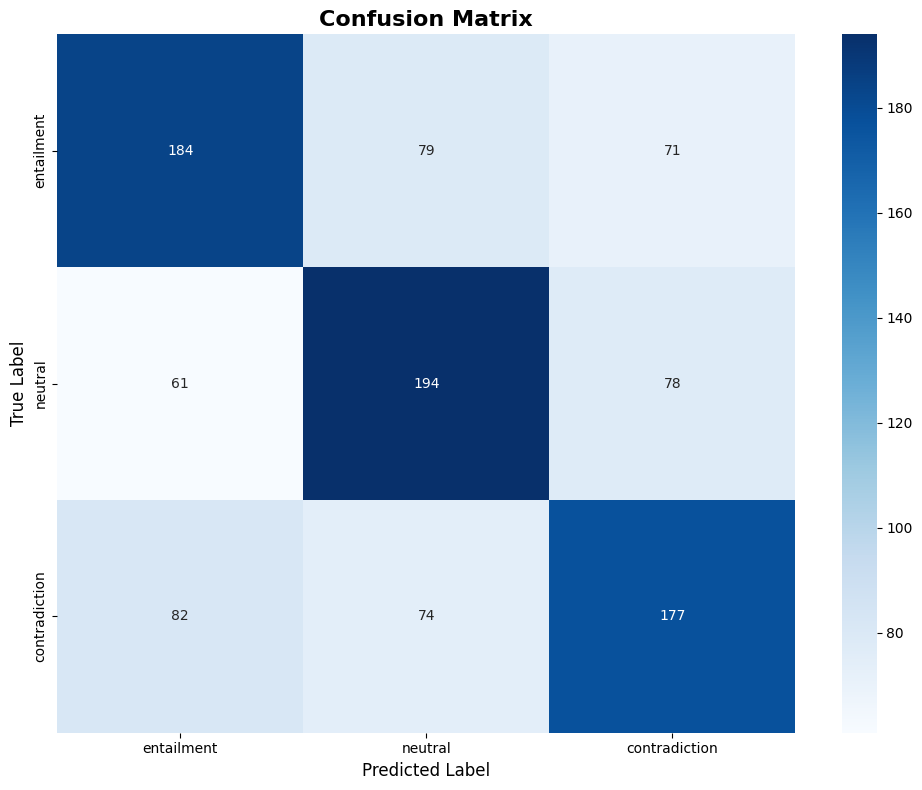


Classification Report:
               precision    recall  f1-score   support

   entailment     0.5627    0.5509    0.5567       334
      neutral     0.5591    0.5826    0.5706       333
contradiction     0.5429    0.5315    0.5372       333

     accuracy                         0.5550      1000
    macro avg     0.5549    0.5550    0.5548      1000
 weighted avg     0.5549    0.5550    0.5548      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_1

🎉 New best on DEV! Accuracy: 0.5550, F1: 0.5548
✓ Saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/best_model

EPOCH 2/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:01<00:00,  3.37it/s, loss=0.13]



✓ Train Loss: 0.2058 | Time: 421.56s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.54it/s]



Accuracy:      0.5820 (58.20%)
Macro F1:      0.5793
Weighted F1:   0.5793


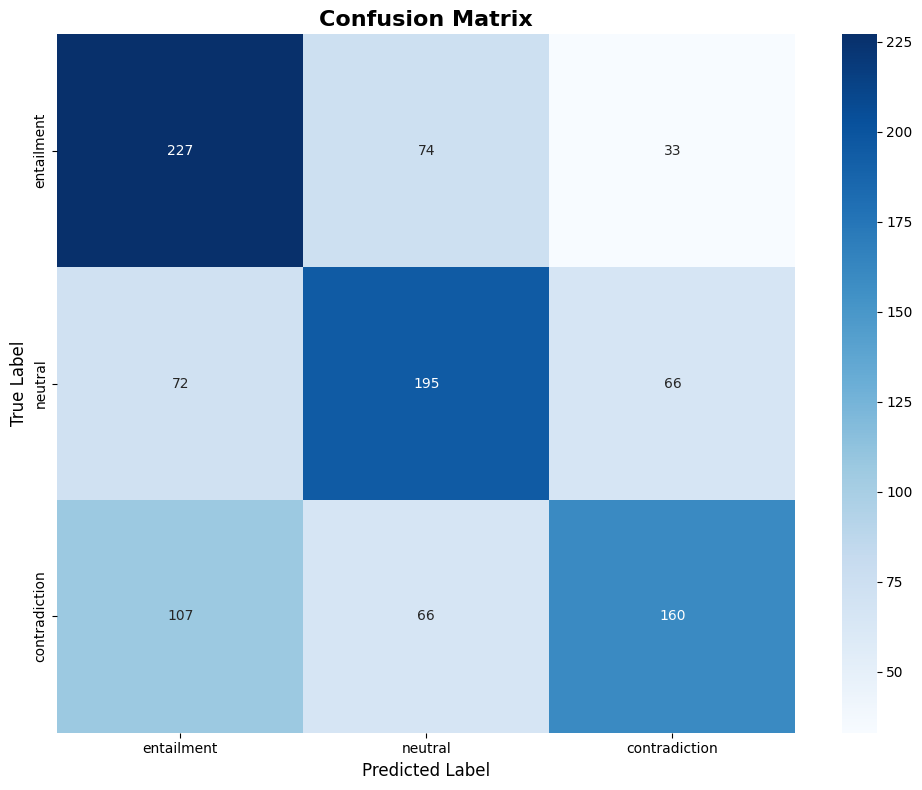


Classification Report:
               precision    recall  f1-score   support

   entailment     0.5591    0.6796    0.6135       334
      neutral     0.5821    0.5856    0.5838       333
contradiction     0.6178    0.4805    0.5405       333

     accuracy                         0.5820      1000
    macro avg     0.5863    0.5819    0.5793      1000
 weighted avg     0.5863    0.5820    0.5793      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_2

🎉 New best on DEV! Accuracy: 0.5820, F1: 0.5793
✓ Saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/best_model

EPOCH 3/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:01<00:00,  3.37it/s, loss=0.0423]



✓ Train Loss: 0.1035 | Time: 421.87s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.54it/s]



Accuracy:      0.6000 (60.00%)
Macro F1:      0.6000
Weighted F1:   0.6000


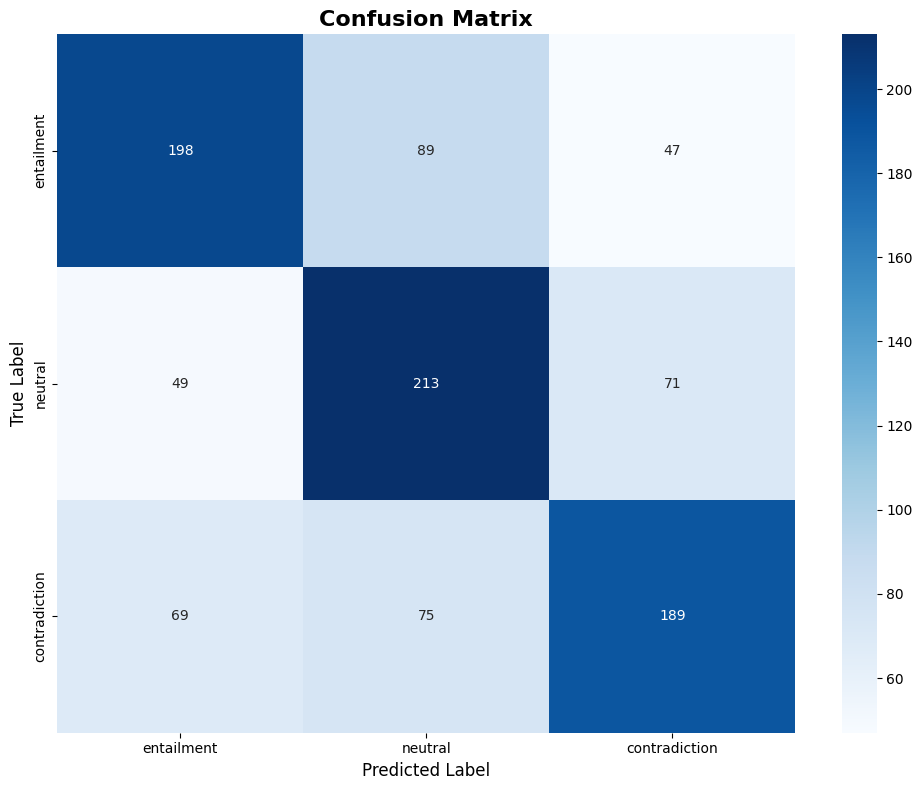


Classification Report:
               precision    recall  f1-score   support

   entailment     0.6266    0.5928    0.6092       334
      neutral     0.5650    0.6396    0.6000       333
contradiction     0.6156    0.5676    0.5906       333

     accuracy                         0.6000      1000
    macro avg     0.6024    0.6000    0.6000      1000
 weighted avg     0.6024    0.6000    0.6000      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_3
✓ Removed old checkpoint: checkpoint_epoch_1

🎉 New best on DEV! Accuracy: 0.6000, F1: 0.6000
✓ Saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/best_model

EPOCH 4/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:01<00:00,  3.37it/s, loss=0.00395]



✓ Train Loss: 0.0597 | Time: 421.83s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.54it/s]



Accuracy:      0.5970 (59.70%)
Macro F1:      0.5963
Weighted F1:   0.5964


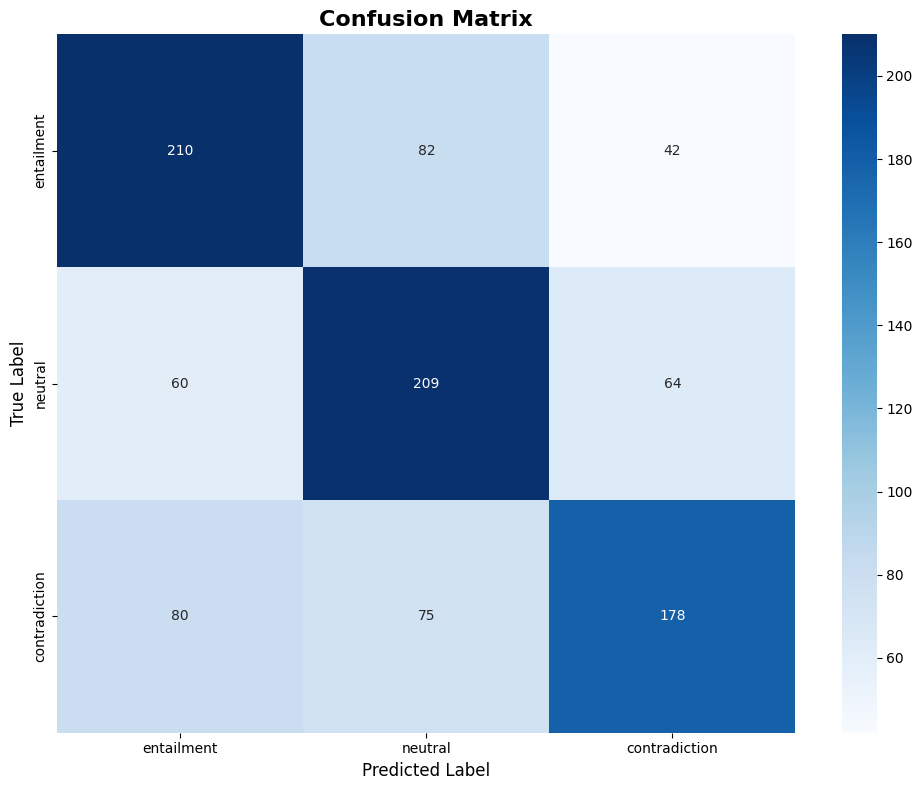


Classification Report:
               precision    recall  f1-score   support

   entailment     0.6000    0.6287    0.6140       334
      neutral     0.5710    0.6276    0.5980       333
contradiction     0.6268    0.5345    0.5770       333

     accuracy                         0.5970      1000
    macro avg     0.5993    0.5970    0.5963      1000
 weighted avg     0.5993    0.5970    0.5964      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_4
✓ Removed old checkpoint: checkpoint_epoch_2

EPOCH 5/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:01<00:00,  3.37it/s, loss=0.00175]



✓ Train Loss: 0.0332 | Time: 421.64s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.54it/s]



Accuracy:      0.6080 (60.80%)
Macro F1:      0.6075
Weighted F1:   0.6075


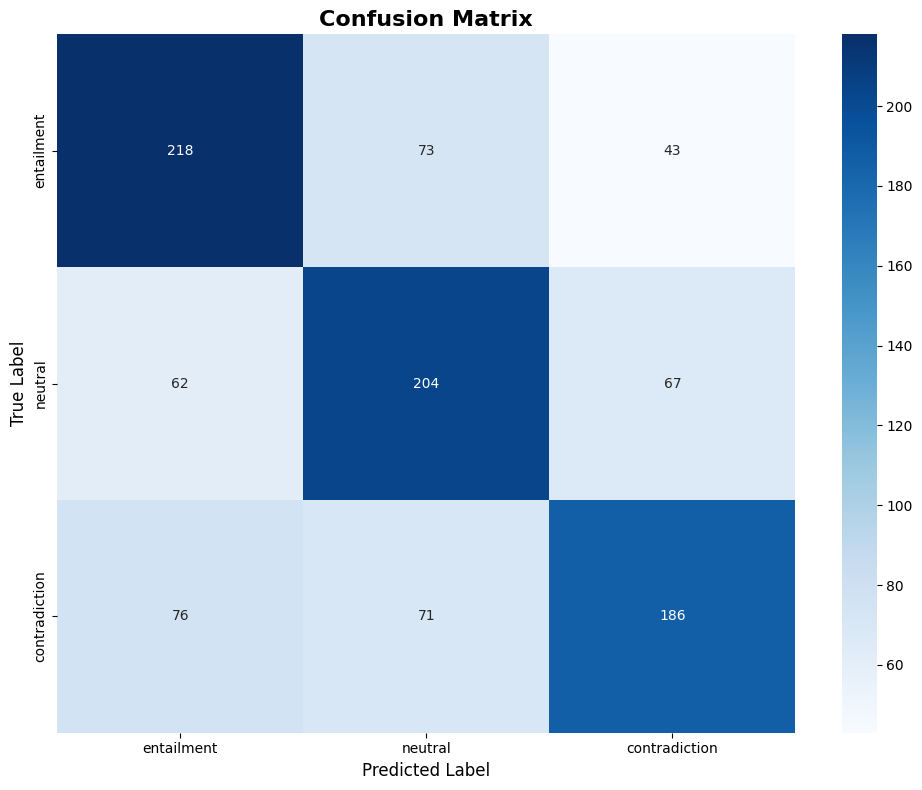


Classification Report:
               precision    recall  f1-score   support

   entailment     0.6124    0.6527    0.6319       334
      neutral     0.5862    0.6126    0.5991       333
contradiction     0.6284    0.5586    0.5914       333

     accuracy                         0.6080      1000
    macro avg     0.6090    0.6080    0.6075      1000
 weighted avg     0.6090    0.6080    0.6075      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_5
✓ Removed old checkpoint: checkpoint_epoch_3

🎉 New best on DEV! Accuracy: 0.6080, F1: 0.6075
✓ Saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/best_model

EPOCH 6/6


Training:   0%|          | 0/1421 [00:00<?, ?it/s]/tmp/ipython-input-3085620719.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
Training: 100%|██████████| 1421/1421 [07:02<00:00,  3.37it/s, loss=0.00131]



✓ Train Loss: 0.0204 | Time: 422.06s

                          DEV SET VALIDATION                          
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.54it/s]



Accuracy:      0.6110 (61.10%)
Macro F1:      0.6098
Weighted F1:   0.6099


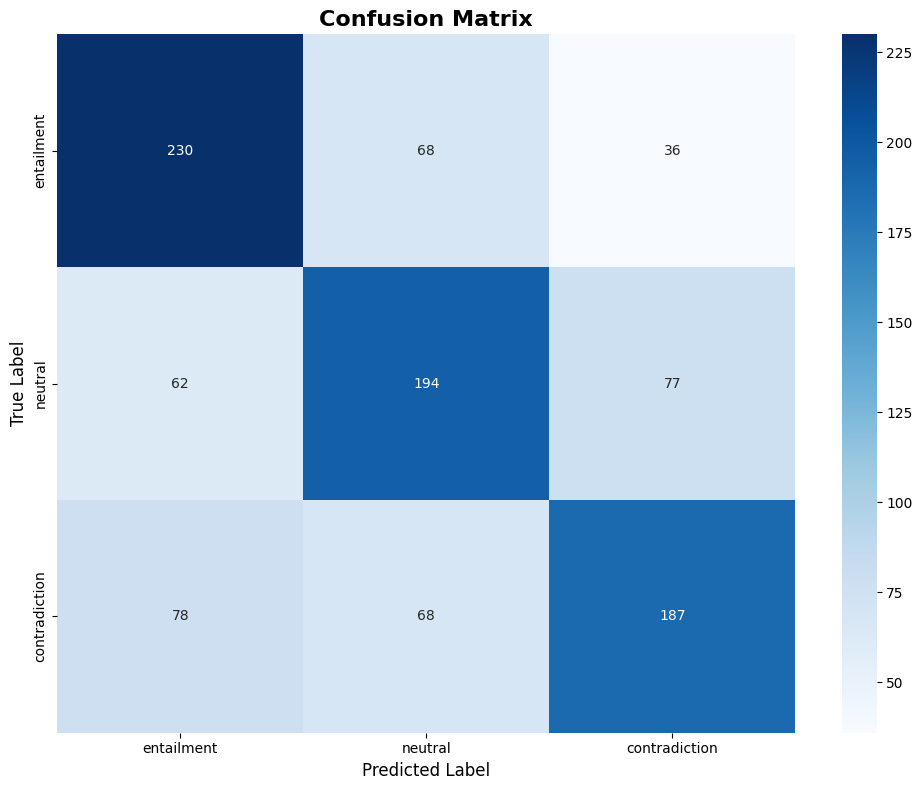


Classification Report:
               precision    recall  f1-score   support

   entailment     0.6216    0.6886    0.6534       334
      neutral     0.5879    0.5826    0.5852       333
contradiction     0.6233    0.5616    0.5908       333

     accuracy                         0.6110      1000
    macro avg     0.6109    0.6109    0.6098      1000
 weighted avg     0.6110    0.6110    0.6099      1000

✓ Checkpoint saved: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/checkpoint_epoch_6
✓ Removed old checkpoint: checkpoint_epoch_4

🎉 New best on DEV! Accuracy: 0.6110, F1: 0.6098
✓ Saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/best_model

                         TRAINING COMPLETED!                          
Total Time:           44.63 minutes
Best DEV Accuracy:    0.6110 (61.10%)
Best DEV Macro F1:    0.6098
Saved to:             /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint



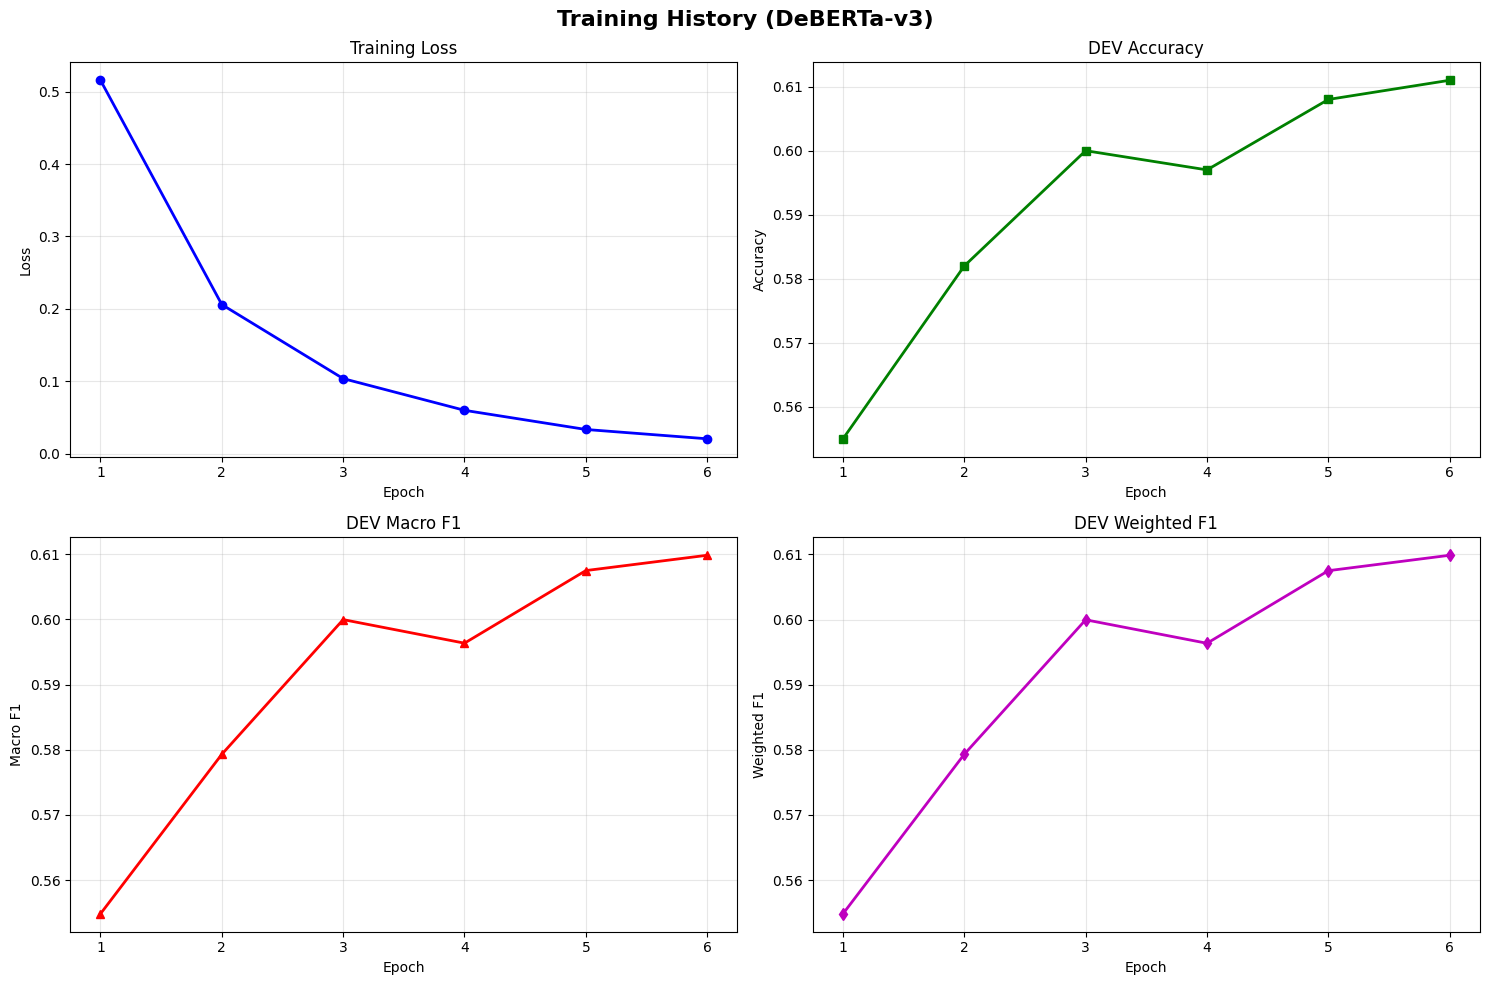

✓ Final model saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/final_model


In [10]:
# ===================================================================
# CELL 10: TRAINING LOOP (RUN THIS!)
# ===================================================================

print("\n" + "="*70)
print("STARTING TRAINING".center(70))
print("="*70)
print(f"Model: {CONFIG['model_name']}")
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Effective Batch Size: {CONFIG['batch_size'] * CONFIG['gradient_accumulation_steps']}")
print(f"Train samples: {len(train_dataset)}")
print(f"Dev samples: {len(dev_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Checkpoints: {CONFIG['save_dir']}")
print("="*70 + "\n")

best_accuracy = 0
best_f1 = 0
training_start = time.time()

training_history = {
    'train_loss': [],
    'dev_accuracy': [],
    'dev_macro_f1': [],
    'dev_weighted_f1': []
}

for epoch in range(CONFIG['num_epochs']):
    epoch_start = time.time()
    print(f"\n{'='*70}")
    print(f"EPOCH {epoch + 1}/{CONFIG['num_epochs']}")
    print(f"{'='*70}")

    # Train
    train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, scaler,
        device, CONFIG['gradient_accumulation_steps'],
        CONFIG['mixed_precision']
    )

    epoch_time = time.time() - epoch_start
    print(f"\n✓ Train Loss: {train_loss:.4f} | Time: {epoch_time:.2f}s")

    # Evaluate on DEV
    print(f"\n{'DEV SET VALIDATION':^70}")
    print("-"*70)
    dev_metrics = evaluate(model, dev_loader, device)

    # Store history
    training_history['train_loss'].append(train_loss)
    training_history['dev_accuracy'].append(dev_metrics['accuracy'])
    training_history['dev_macro_f1'].append(dev_metrics['macro_f1'])
    training_history['dev_weighted_f1'].append(dev_metrics['weighted_f1'])

    # Save checkpoint
    if CONFIG['save_every_epoch']:
        epoch_metrics = {
            'train_loss': train_loss,
            'dev_accuracy': dev_metrics['accuracy'],
            'dev_macro_f1': dev_metrics['macro_f1'],
            'dev_weighted_f1': dev_metrics['weighted_f1']
        }
        save_checkpoint(model, tokenizer, epoch + 1,
                       epoch_metrics, CONFIG['save_dir'])
        cleanup_old_checkpoints(CONFIG['save_dir'],
                               CONFIG['keep_last_n_checkpoints'])

    # Save best model
    if dev_metrics['accuracy'] > best_accuracy:
        best_accuracy = dev_metrics['accuracy']
        best_f1 = dev_metrics['macro_f1']
        print(f"\n🎉 New best on DEV! Accuracy: {best_accuracy:.4f}, F1: {best_f1:.4f}")

        best_model_path = f"{CONFIG['save_dir']}/best_model"
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"✓ Saved to: {best_model_path}")

total_time = time.time() - training_start

print(f"\n{'='*70}")
print("TRAINING COMPLETED!".center(70))
print(f"{'='*70}")
print(f"Total Time:           {total_time/60:.2f} minutes")
print(f"Best DEV Accuracy:    {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Best DEV Macro F1:    {best_f1:.4f}")
print(f"Saved to:             {CONFIG['save_dir']}")
print(f"{'='*70}\n")

# Plot history
plot_training_history(training_history,
                     f"{CONFIG['save_dir']}/training_history.png")

# Save final model
final_path = f"{CONFIG['save_dir']}/final_model"
model.save_pretrained(final_path)
tokenizer.save_pretrained(final_path)
print(f"✓ Final model saved to: {final_path}")


In [11]:
# ===================================================================
# CELL 11: Test Single Predictions
# ===================================================================

def predict(premise, hypothesis, model, tokenizer, device):
    """Make a single prediction"""
    model.eval()

    encoding = tokenizer(
        premise,
        hypothesis,
        max_length=CONFIG['max_length'],
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]
        pred_id = torch.argmax(logits, dim=-1).item()

    pred_label = LABEL_MAP[pred_id]

    print(f"\nPremise: {premise}")
    print(f"Hypothesis: {hypothesis}")
    print(f"\nPrediction: {pred_label.upper()}")
    print(f"Confidence:")
    for i, label in LABEL_MAP.items():
        print(f"  {label}: {probs[i]:.4f}")

    return pred_label

print("\n" + "="*70)
print("TESTING PREDICTIONS".center(70))
print("="*70)

predict(
    premise="A man is playing guitar on stage.",
    hypothesis="A musician is performing.",
    model=model,
    tokenizer=tokenizer,
    device=device
)

predict(
    premise="The dog is sleeping on the couch.",
    hypothesis="The cat is awake.",
    model=model,
    tokenizer=tokenizer,
    device=device
)


                         TESTING PREDICTIONS                          

Premise: A man is playing guitar on stage.
Hypothesis: A musician is performing.

Prediction: ENTAILMENT
Confidence:
  entailment: 0.9997
  neutral: 0.0002
  contradiction: 0.0001

Premise: The dog is sleeping on the couch.
Hypothesis: The cat is awake.

Prediction: NEUTRAL
Confidence:
  entailment: 0.0001
  neutral: 0.9998
  contradiction: 0.0001


'neutral'


                     FINAL EVALUATION ON TEST SET                     

Loading best model...
✓ Best model loaded!

Evaluating on TEST set (1000 samples)...
This is the FINAL, UNBIASED evaluation.
----------------------------------------------------------------------

Evaluating on 1000 samples...


Evaluating: 100%|██████████| 32/32 [00:12<00:00,  2.53it/s]



Accuracy:      0.6180 (61.80%)
Macro F1:      0.6177
Weighted F1:   0.6177


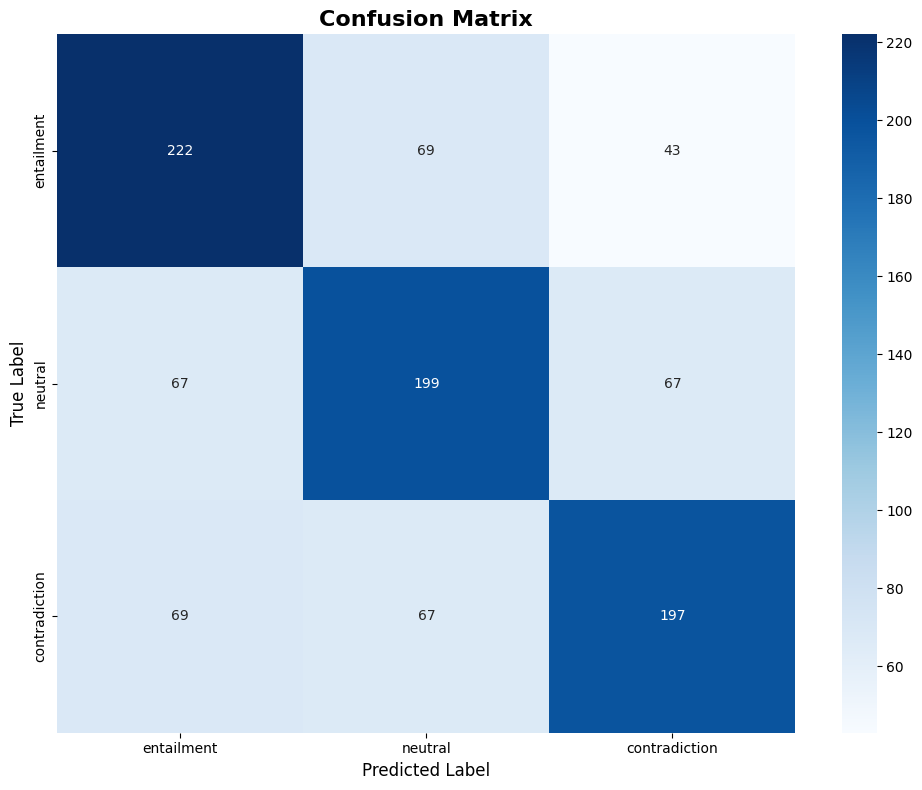


Classification Report:
               precision    recall  f1-score   support

   entailment     0.6201    0.6647    0.6416       334
      neutral     0.5940    0.5976    0.5958       333
contradiction     0.6417    0.5916    0.6156       333

     accuracy                         0.6180      1000
    macro avg     0.6186    0.6180    0.6177      1000
 weighted avg     0.6186    0.6180    0.6177      1000


                        FINAL TEST SET RESULTS                        
Test Accuracy:      0.6180 (61.80%)
Test Macro F1:      0.6177
Test Weighted F1:   0.6177

Best DEV Accuracy:  0.6110
Final TEST Accuracy: 0.6180

✓ Test results saved!


In [12]:
# ===================================================================
# CELL 12: FINAL TEST SET EVALUATION
# ===================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON TEST SET".center(70))
print("="*70)
print("\nLoading best model...")

best_model_path = f"{CONFIG['save_dir']}/best_model"
model_test = AutoModelForSequenceClassification.from_pretrained(best_model_path).to(device)
tokenizer_test = AutoTokenizer.from_pretrained(best_model_path)

print("✓ Best model loaded!")
print(f"\nEvaluating on TEST set ({len(test_dataset)} samples)...")
print("This is the FINAL, UNBIASED evaluation.")
print("-"*70)

test_metrics = evaluate(model_test, test_loader, device)

print(f"\n{'='*70}")
print("FINAL TEST SET RESULTS".center(70))
print(f"{'='*70}")
print(f"Test Accuracy:      {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
print(f"Test Macro F1:      {test_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1:   {test_metrics['weighted_f1']:.4f}")
print(f"{'='*70}")
print(f"\nBest DEV Accuracy:  {best_accuracy:.4f}")
print(f"Final TEST Accuracy: {test_metrics['accuracy']:.4f}")
print(f"{'='*70}\n")

# Save test results
test_results = {
    'model': CONFIG['model_name'],
    'test_accuracy': float(test_metrics['accuracy']),
    'test_macro_f1': float(test_metrics['macro_f1']),
    'test_weighted_f1': float(test_metrics['weighted_f1']),
    'best_dev_accuracy': float(best_accuracy),
    'best_dev_macro_f1': float(best_f1),
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open(f"{CONFIG['save_dir']}/test_results.json", 'w') as f:
    json.dump(test_results, f, indent=2)

print(f"✓ Test results saved!")

In [13]:
# ===================================================================
# CELL 13: Generate All Test Predictions (CSV)
# ===================================================================

def generate_all_predictions(model, dataset, tokenizer, device, save_path):
    """Generate predictions for all test samples and save as CSV"""
    model.eval()
    results = []

    print(f"Generating predictions for {len(dataset)} samples...")

    with torch.no_grad():
        for idx in tqdm(range(len(dataset)), desc="Generating"):
            sample = dataset.data[idx]
            premise = sample['premise']
            hypothesis = sample['hypothesis']
            true_label = sample['label']

            encoding = tokenizer(
                premise,
                hypothesis,
                max_length=CONFIG['max_length'],
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )

            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred_id = torch.argmax(outputs.logits, dim=-1).item()

            results.append({
                'sample_id': idx,
                'premise': premise,
                'hypothesis': hypothesis,
                'true_label': LABEL_MAP[true_label],
                'predicted_label': LABEL_MAP[pred_id],
                'is_correct': (pred_id == true_label)
            })

    df = pd.DataFrame(results)
    df.to_csv(save_path, index=False)

    print(f"\n✓ Saved {len(df)} predictions to: {save_path}")
    print(f"✓ Accuracy: {df['is_correct'].mean()*100:.2f}%")

    return df

# Generate predictions
predictions_df = generate_all_predictions(
    model=model_test,
    dataset=test_dataset,
    tokenizer=tokenizer_test,
    device=device,
    save_path=f"{CONFIG['save_dir']}/test_predictions.csv"
)

print("\nFirst 5 predictions:")
print(predictions_df.head())

Generating predictions for 1000 samples...


Generating: 100%|██████████| 1000/1000 [00:45<00:00, 21.94it/s]



✓ Saved 1000 predictions to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/test_predictions.csv
✓ Accuracy: 61.80%

First 5 predictions:
   sample_id                                            premise  \
0          0  There is a little Shia community in El Salvado...   
1          1  "Look at Me (When I Rock Wichoo)" is a song by...   
2          2  "Eternally" is a song with music by Charles Ch...   
3          3  Louis S. Peterson (June 17, 1922 – April 27, 1...   
4          4  Things Happen at Night is a 1947 British super...   

                                          hypothesis     true_label  \
0       The community is south of the United States.     entailment   
1  The song was released in America in September ...        neutral   
2  The words to Eternally were written partially ...     entailment   
3  Louis S. Peterson was an adult when he wrote h...        neutral   
4   Frank Harvey Jnr. wrote Things Happen at Night .  contradiction   

  predicted_label  is_correct  

In [14]:
# ===================================================================
# CELL 14: Performance Comparison
# ===================================================================

print("\n" + "="*70)
print("PERFORMANCE COMPARISON".center(70))
print("="*70)

comparison = pd.DataFrame({
    'Split': ['DEV (Validation)', 'TEST (Final)'],
    'Accuracy': [best_accuracy, test_metrics['accuracy']],
    'Macro F1': [best_f1, test_metrics['macro_f1']],
    'Weighted F1': [training_history['dev_weighted_f1'][-1],
                    test_metrics['weighted_f1']]
})

print(f"\n{comparison.to_string(index=False)}")

accuracy_diff = test_metrics['accuracy'] - best_accuracy
print(f"\n{'='*70}")
if abs(accuracy_diff) < 0.02:
    print("✓ Good generalization! DEV and TEST performance are similar.")
elif accuracy_diff > 0:
    print("✓ Model performs better on TEST than DEV!")
else:
    print(" Model performs worse on TEST than DEV.")
print(f"  Accuracy difference: {accuracy_diff:+.4f} ({accuracy_diff*100:+.2f}%)")
print(f"{'='*70}\n")


print(f"\n✓ All results saved to: {CONFIG['save_dir']}/")
print(" Training and evaluation complete!")


                        PERFORMANCE COMPARISON                        

           Split  Accuracy  Macro F1  Weighted F1
DEV (Validation)     0.611  0.609822     0.609865
    TEST (Final)     0.618  0.617684     0.617708

✓ Good generalization! DEV and TEST performance are similar.
  Accuracy difference: +0.0070 (+0.70%)


✓ All results saved to: /content/drive/MyDrive/DeBERTa_ANLI_Checkpoint/
 Training and evaluation complete!
